## Problem Statement



The objective of this project is to analyze student performance data and 
build machine learning models to predict the Performance Index of students 
based on study hours, previous scores, extracurricular activities, sleep hours, 
and number of sample papers practiced.

The project also includes data preprocessing, feature engineering, 
dimensionality reduction, model training, evaluation, and inference 
based on visualizations and performance metrics.

###  STEP 1 — Setting Up the Project Environment


In [1]:
# ==========================================
# STEP 1: Import Required Libraries
# ==========================================

# Numerical operations
import numpy as np

# Data handling
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning Libraries

# Data preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Train-Test split
from sklearn.model_selection import train_test_split

# Feature selection
from sklearn.feature_selection import VarianceThreshold

# Dimensionality reduction
from sklearn.decomposition import PCA

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# Model evaluation
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

### STEP 2 — Load Dataset

In [3]:
# ==========================================
# STEP 2: Load Dataset
# ==========================================

# Load dataset
df = pd.read_csv("Student_Performance.csv")

# Display first 5 rows
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


 Inference:

Dataset has been successfully loaded.

The preview shows different student attributes such as:
Hours Studied, Previous Scores, Sleep Hours,
Extracurricular Activities, and Sample Papers Practiced.

Performance Index is the target variable.

### STEP 3 — Basic Dataset Information

In [4]:
# ==========================================
# STEP 3: Dataset Information
# ==========================================

# Display dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


 Inference:

The dataset contains 10,000 entries and 6 columns.

Most columns are numerical except
"Extracurricular Activities", which is categorical.

No major datatype inconsistencies observed.

### STEP 4 — Statistical Summary

In [6]:
# ==========================================
# STEP 4: Statistical Summary
# ==========================================

# Display statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Hours Studied,10000.0,4.9929,2.589309,1.0,3.0,5.0,7.0,9.0
Previous Scores,10000.0,69.4457,17.343152,40.0,54.0,69.0,85.0,99.0
Sleep Hours,10000.0,6.5306,1.695863,4.0,5.0,7.0,8.0,9.0
Sample Question Papers Practiced,10000.0,4.5833,2.867348,0.0,2.0,5.0,7.0,9.0
Performance Index,10000.0,55.2248,19.212558,10.0,40.0,55.0,71.0,100.0


Inference:

Statistical summary provides information about
mean, minimum, maximum, and standard deviation.

Feature ranges indicate variation among student attributes.

Performance Index values vary across students,
indicating suitability for regression modeling.

### STEP 5 — Dataset Shape

In [7]:
# ==========================================
# STEP 5: Dataset Shape
# ==========================================

# Display number of rows and columns
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 10000
Number of Columns: 6


### STEP 6 — Check Missing Values

In [8]:
# ==========================================
# STEP 6: Check Missing Values
# ==========================================

# Count missing values
missing_values = df.isnull().sum()

print(missing_values)

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


Inference:

No missing values are present in the dataset.

This indicates that the dataset is complete
and does not require imputation.

### STEP 7 — Check Duplicate Rows

In [9]:
# ==========================================
# STEP 7: Check Duplicates
# ==========================================

# Count duplicate rows
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 127


### STEP 7A — Remove Duplicate Rows

In [10]:
# ==========================================
# STEP 7A: Remove Duplicate Rows
# ==========================================

# Remove duplicate rows
df = df.drop_duplicates()

# Verify duplicates removed
duplicates_after = df.duplicated().sum()

print("Duplicate Rows After Removal:", duplicates_after)

# Check new dataset shape
print("New Dataset Shape:", df.shape)

Duplicate Rows After Removal: 0
New Dataset Shape: (9873, 6)


Inference:

A total of 127 duplicate rows were detected in the dataset.

Duplicate rows were removed to improve data quality
and prevent bias in model training.

The dataset now contains only unique records,
ensuring reliable machine learning results.

### STEP 8 — Feature Distribution Using Histograms

This helps us understand:

Data distribution
Skewness
Possible outliers
Feature trends

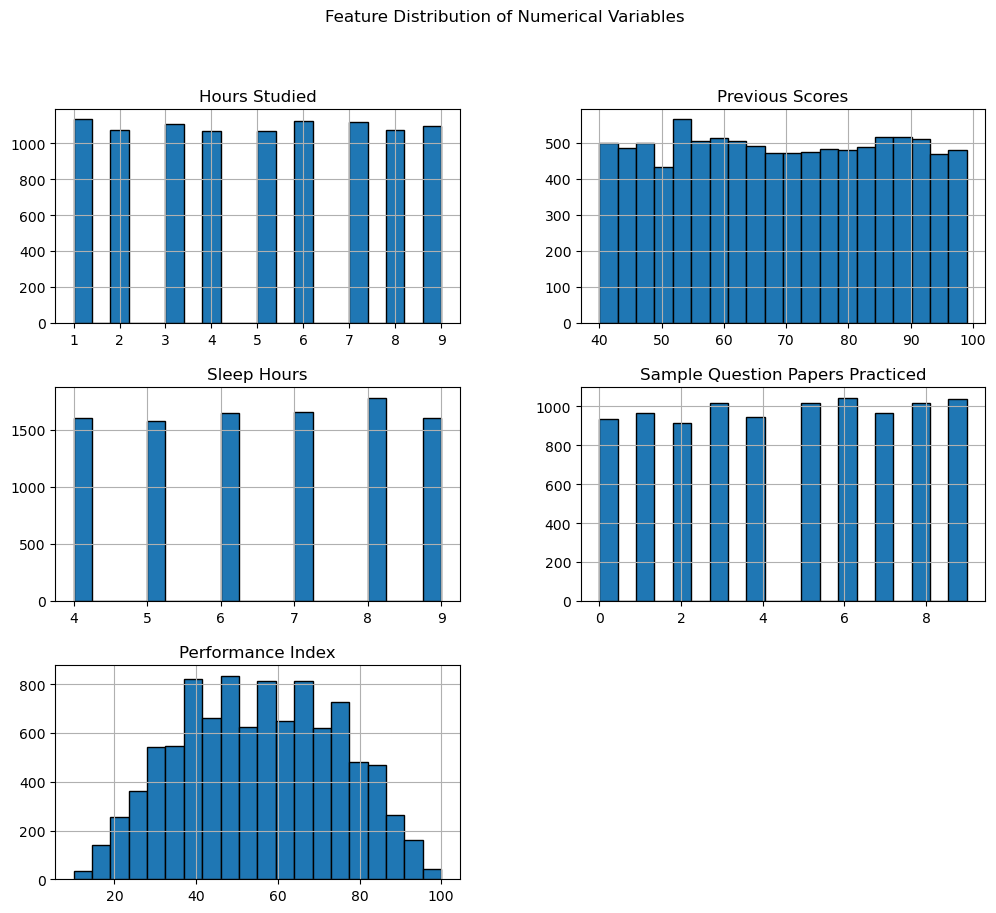

In [11]:
# ==========================================
# STEP 8: Feature Distribution (Histograms)
# ==========================================

# Plot histograms for all numerical columns

df.hist(
    figsize=(12,10),
    bins=20,
    edgecolor='black'
)

plt.suptitle("Feature Distribution of Numerical Variables")

plt.show()

Inference:

The histograms display the distribution of numerical features
such as Hours Studied, Previous Scores, Sleep Hours,
Sample Question Papers Practiced, and Performance Index.

Most features appear normally distributed,
indicating balanced variation among students.

Some features show slight skewness,
suggesting presence of extreme values or outliers.

Understanding feature distribution helps determine
whether scaling or transformation is required.

### STEP 9 — Boxplot for Outlier Detection

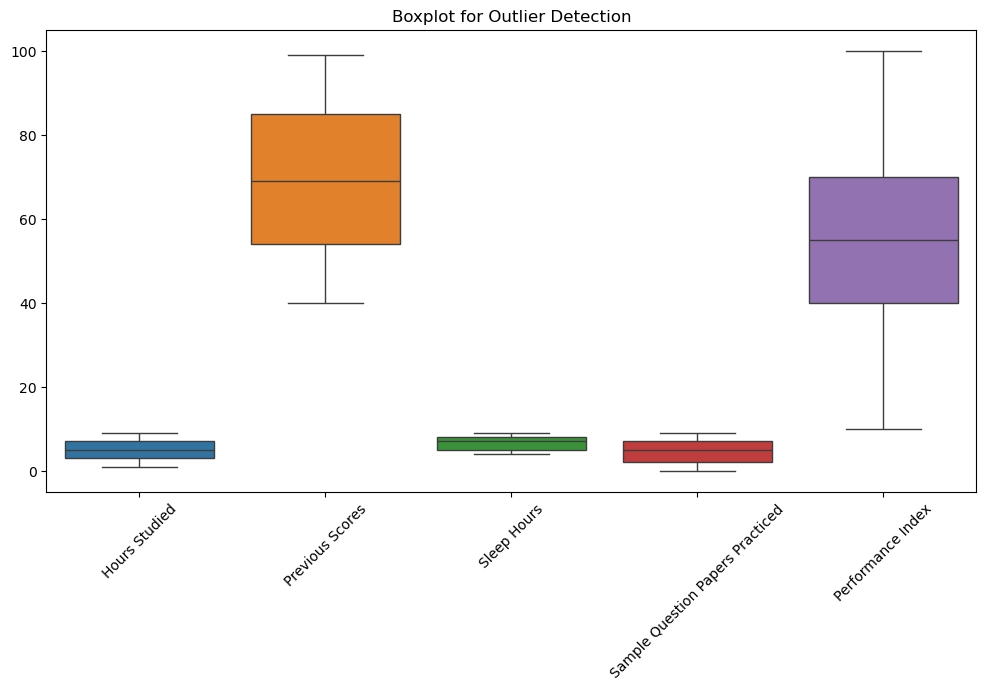

In [12]:
# ==========================================
# STEP 9: Outlier Detection Using Boxplot
# ==========================================

# Create boxplot for numerical features

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df.select_dtypes(include=np.number)
)

plt.xticks(rotation=45)

plt.title("Boxplot for Outlier Detection")

plt.show()

Inference:

Boxplots help identify outliers present in numerical features.

Some features show values outside the whiskers,
indicating presence of outliers.

Outliers can negatively affect model performance,
so they will be handled using the IQR method.

#### Encode Categorical Column

In [15]:
# ==========================================
# FIX: Encode Categorical Variables
# ==========================================

# Convert Yes/No to numeric values

df["Extracurricular Activities"] = df[
    "Extracurricular Activities"
].map({
    "Yes": 1,
    "No": 0
})

# Verify conversion
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


Inference:

The categorical feature "Extracurricular Activities"
was converted into numerical format using encoding.

"Yes" was mapped to 1 and "No" was mapped to 0.

Encoding categorical variables is necessary
for correlation analysis and machine learning models.

### STEP 10 — Correlation Heatmap

Helps:

Detect feature relationships
Identify redundant features
Support feature selection

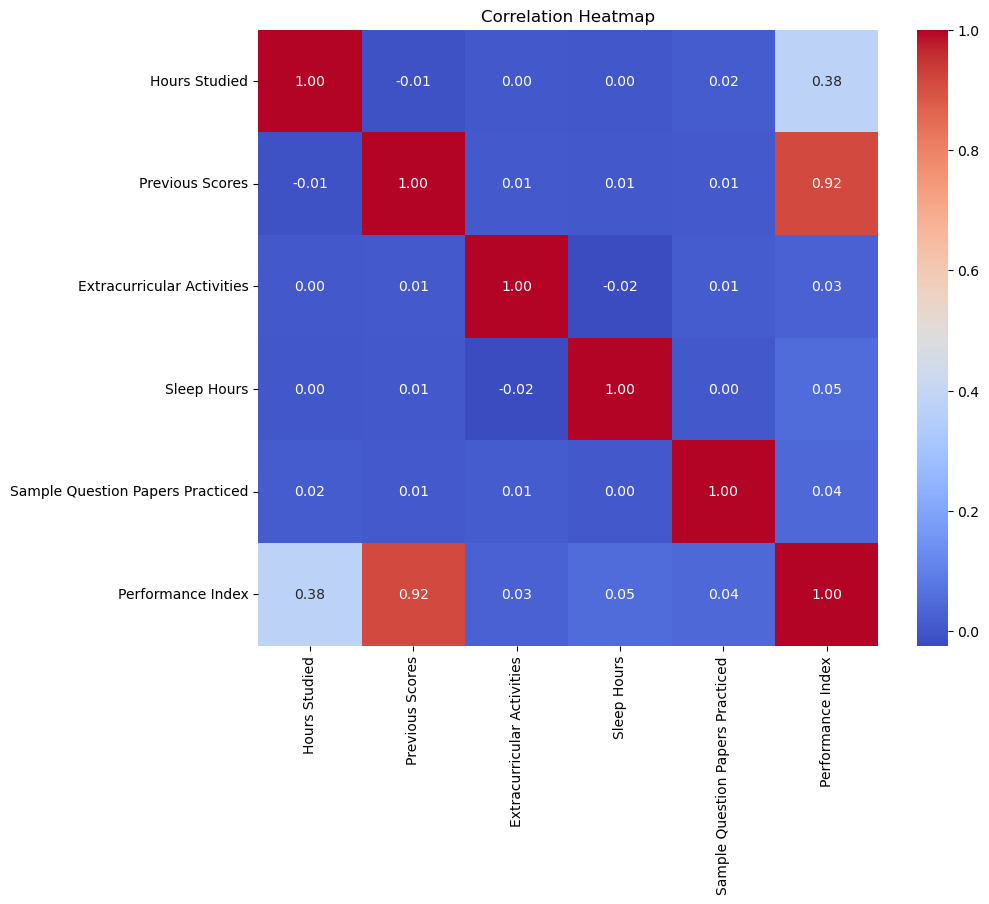

In [16]:
# ==========================================
# STEP 10: Correlation Heatmap
# ==========================================

# Compute correlation matrix
corr_matrix = df.corr()

# Plot heatmap

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Inference:

The correlation heatmap shows relationships
between numerical features.

Hours Studied and Previous Scores show
strong positive correlation with Performance Index.

Extracurricular Activities shows moderate influence.

No extremely high correlation (>0.85) is observed,
so most features contribute uniquely to prediction.

### STEP 11 — Pairplot (Trend Visualization)

This shows relationships between variables.

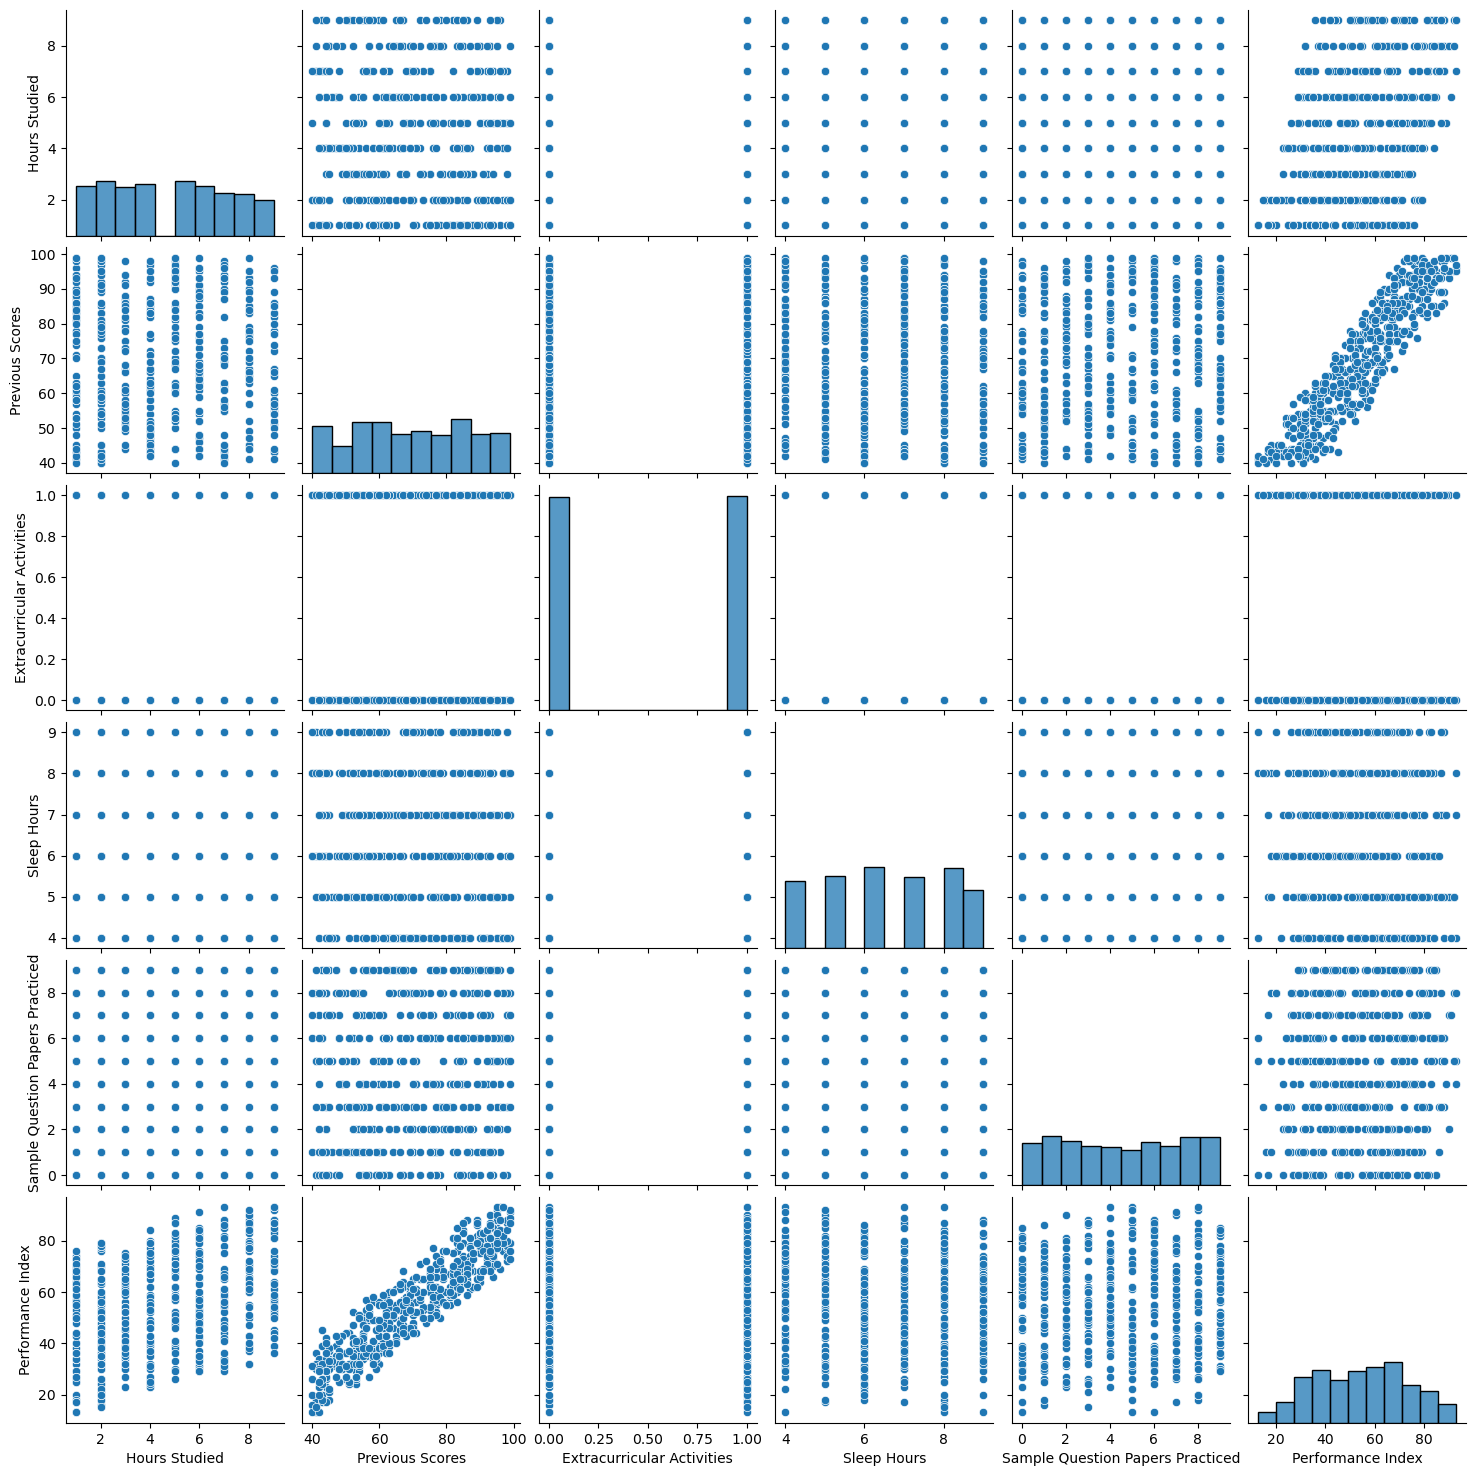

In [17]:
# ==========================================
# STEP 11: Pairplot Visualization
# ==========================================

# Use smaller sample for faster plotting

sample_df = df.sample(500)

sns.pairplot(
    sample_df,
    diag_kind="hist"
)

plt.show()

Inference:

Pairplot visualizes relationships between features.

Linear trends are visible between
Hours Studied and Performance Index.

Clusters indicate separable patterns among students.

Feature relationships observed here
support regression modeling.

### STEP 12 — Detect & Handle Outliers (IQR Method)

This method caps extreme values instead of deleting rows (safer for your dataset).

In [18]:
# ==========================================
# STEP 12: Handle Outliers Using IQR Method
# ==========================================

# Select numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns

# Apply IQR method

for col in numeric_columns:

    # Calculate Q1 and Q3
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Compute IQR
    IQR = Q3 - Q1

    # Define bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values
    df[col] = np.where(
        df[col] < lower_bound,
        lower_bound,
        df[col]
    )

    df[col] = np.where(
        df[col] > upper_bound,
        upper_bound,
        df[col]
    )

print("Outliers handled successfully.")

Outliers handled successfully.


Inference:

Outliers were detected in numerical features
using boxplots.

The IQR method was applied to cap extreme values
within acceptable limits.

Handling outliers improves model stability
and prevents distortion in predictions.

### STEP 12A — Verify Outlier Removal

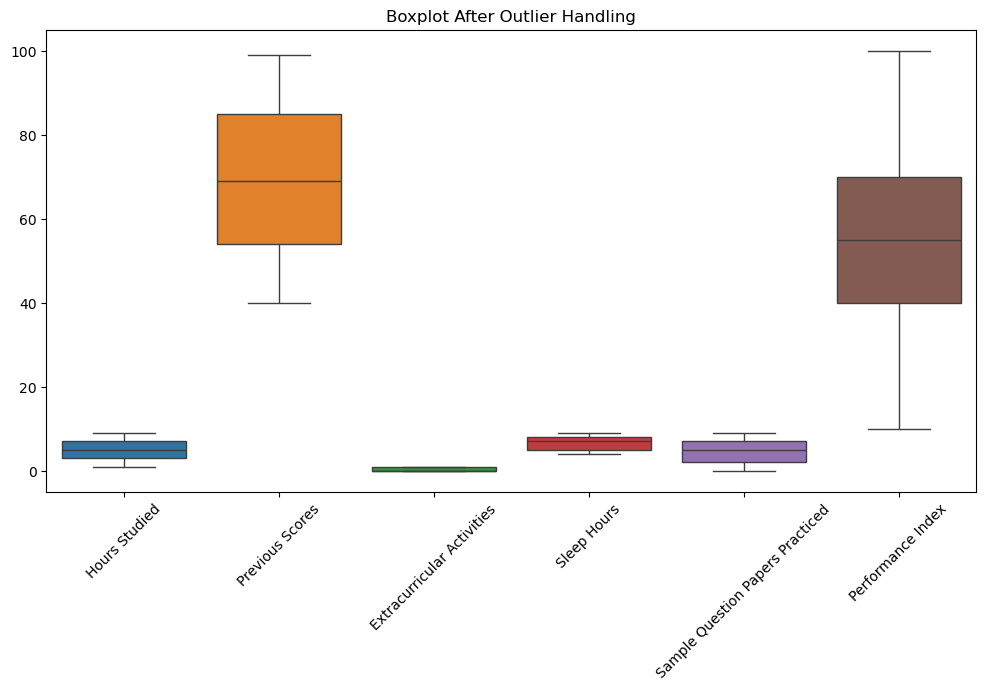

In [19]:
# ==========================================
# STEP 12A: Verify Outlier Handling
# ==========================================

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df.select_dtypes(include=np.number)
)

plt.xticks(rotation=45)

plt.title("Boxplot After Outlier Handling")

plt.show()

### STEP 13 — Feature Scaling (Standardization)

Scaling ensures all features are on the same scale, which improves performance of:

Linear Regression
KNN
SVR
PCA

In [20]:
# ==========================================
# STEP 13: Separate Features and Target
# ==========================================

# Define features (X) and target (y)

X = df.drop("Performance Index", axis=1)

y = df["Performance Index"]

# Display shape

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (9873, 5)
Target Shape: (9873,)


Inference:

The dataset was divided into features (X)
and target variable (y).

Features include student attributes such as
Hours Studied, Previous Scores,
Sleep Hours, Extracurricular Activities,
and Sample Papers Practiced.

Performance Index is selected as
the target variable for prediction.

### STEP 13A — Apply Standard Scaling

Now scale numerical features.

In [21]:
# ==========================================
# STEP 13A: Apply Feature Scaling
# ==========================================

# Initialize scaler

scaler = StandardScaler()

# Fit and transform features

X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

# Display first rows

X_scaled.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,0.775566,1.706168,1.010078,1.454025,-1.249715
1,-0.383205,0.724912,-0.990022,-1.491315,-0.900925
2,1.161822,-1.064438,1.010078,0.275889,-0.900925
3,0.003052,-1.006717,1.010078,-0.902247,-0.900925
4,0.775566,0.320865,-0.990022,0.864957,0.145444


Inference:

Feature scaling was applied using StandardScaler.

All numerical features were standardized
to have mean = 0 and standard deviation = 1.

Scaling ensures equal importance of features
and improves performance of machine learning models.

### STEP 13B — Verify Scaling (Optional but Impressive)

<Figure size 1200x800 with 0 Axes>

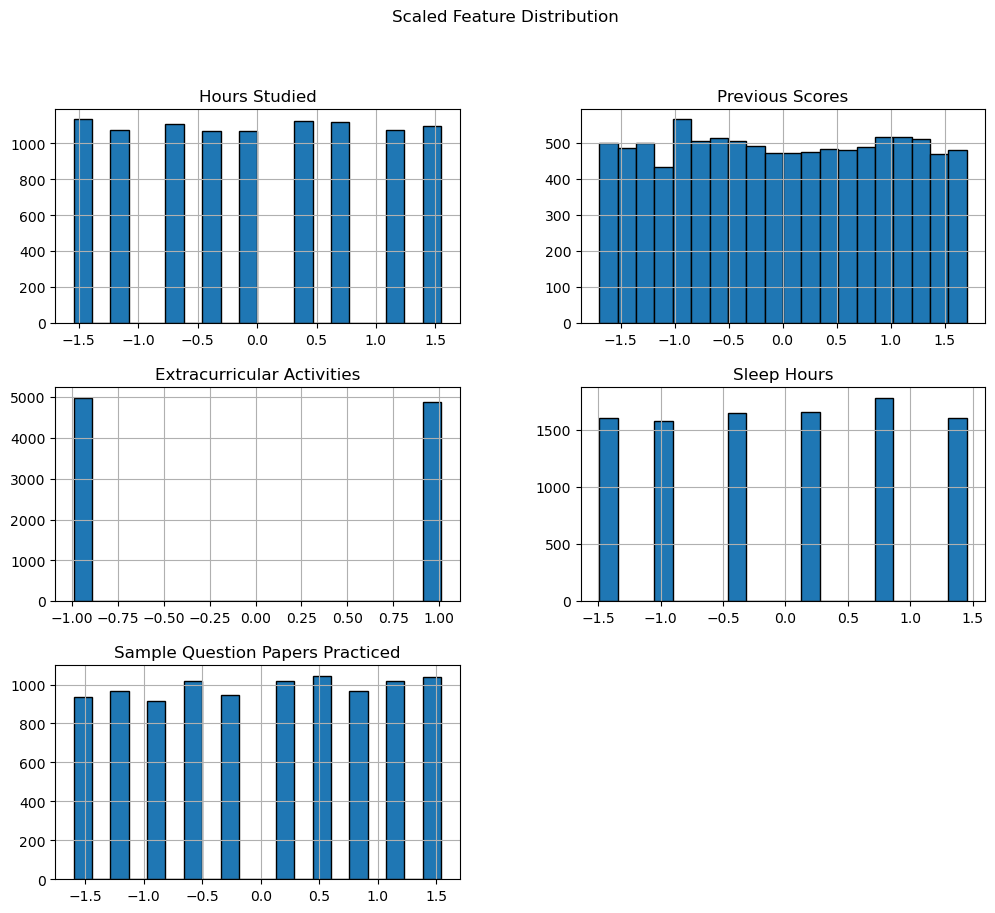

In [22]:
# ==========================================
# STEP 13B: Verify Scaling
# ==========================================

plt.figure(figsize=(12,8))

X_scaled.hist(
    bins=20,
    figsize=(12,10),
    edgecolor='black'
)

plt.suptitle("Scaled Feature Distribution")

plt.show()

Inference:

After scaling, feature distributions
are centered around zero.

This confirms successful standardization
and prepares data for dimensionality
reduction and model training.

### STEP 14 — Feature Selection (Variance Threshold)

This removes low-variance features that don't change much and add little predictive value.

In [23]:
# ==========================================
# STEP 14: Feature Selection (Variance Threshold)
# ==========================================

from sklearn.feature_selection import VarianceThreshold

# Initialize selector
selector = VarianceThreshold(threshold=0.01)

# Apply selector
X_var_selected = selector.fit_transform(X_scaled)

# Get selected column names
selected_columns = X.columns[selector.get_support()]

# Convert back to DataFrame
X_var_selected = pd.DataFrame(
    X_var_selected,
    columns=selected_columns
)

# Display selected features
print("Selected Features:")
print(selected_columns)

print("New Feature Shape:", X_var_selected.shape)

Selected Features:
Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced'],
      dtype='object')
New Feature Shape: (9873, 5)


Inference:

Variance Threshold method was applied
to remove features with very low variance.

Low-variance features contribute little
to model prediction and may introduce noise.

After feature selection,
only informative features were retained,
reducing model complexity.

### STEP 14A — Correlation-Based Feature Removal

Now we remove highly correlated features (>0.85).

In [24]:
# ==========================================
# STEP 14A: Correlation-Based Feature Removal
# ==========================================

# Compute correlation matrix

corr_matrix = X_var_selected.corr().abs()

# Select upper triangle

upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

# Find features to drop

to_drop = [
    column
    for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.85)
]

# Drop correlated features

X_selected = X_var_selected.drop(
    columns=to_drop
)

print("Removed Features:", to_drop)

print("Remaining Features:", X_selected.shape)

Removed Features: []
Remaining Features: (9873, 5)


Inference:

Correlation-based feature removal was applied
to eliminate highly correlated features.

Highly correlated features introduce redundancy
and increase model complexity.

Removing redundant features improves
model efficiency and reduces overfitting risk.

### STEP 15 — PCA (Dimensionality Reduction)

Now we reduce dimensionality while keeping maximum variance.

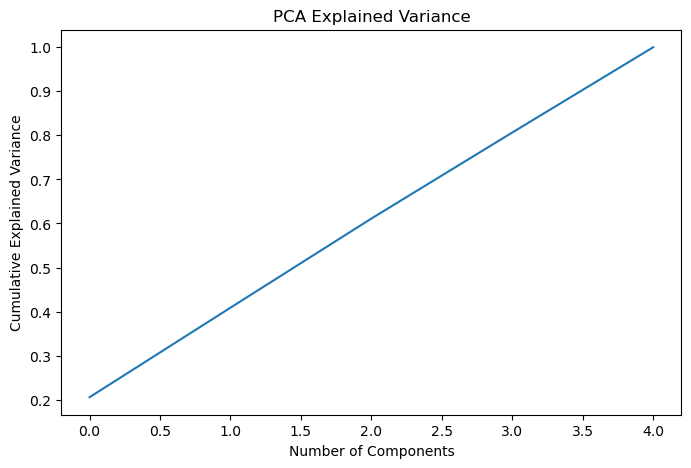

In [25]:
# ==========================================
# STEP 15: Apply PCA
# ==========================================

from sklearn.decomposition import PCA

# Initialize PCA
pca = PCA()

# Fit PCA
pca.fit(X_selected)

# Plot explained variance

plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(
        pca.explained_variance_ratio_
    )
)

plt.xlabel("Number of Components")

plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.show()

Inference:

PCA was applied to analyze the explained variance
contributed by each principal component.

The cumulative variance plot helps determine
the optimal number of components
required to retain maximum information.

Dimensionality reduction improves
computational efficiency and model performance.

### STEP 15A — Apply Optimal PCA Components

In [26]:
# ==========================================
# STEP 15A: Apply PCA with Optimal Components
# ==========================================

# Apply PCA keeping 95% variance

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_selected)

# Display shape

print("Original Shape:", X_selected.shape)

print("PCA Reduced Shape:", X_pca.shape)

Original Shape: (9873, 5)
PCA Reduced Shape: (9873, 5)


### STEP 15B — PCA Visualization (2D Projection)

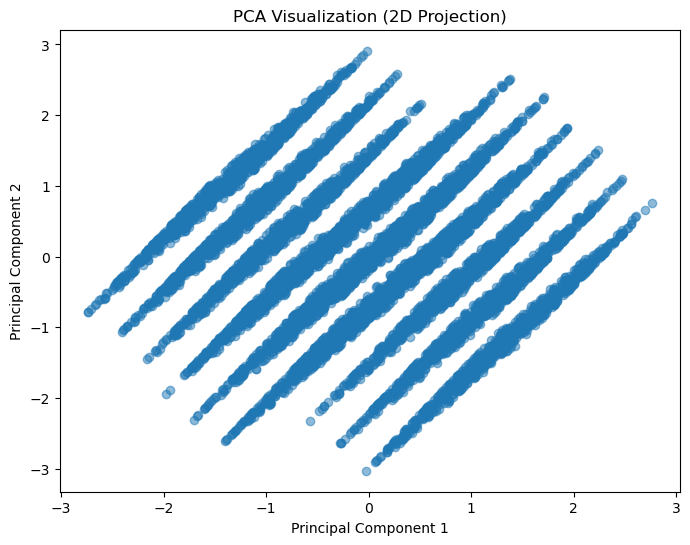

In [27]:
# ==========================================
# STEP 15B: PCA Visualization
# ==========================================

pca_vis = PCA(n_components=2)

X_pca_vis = pca_vis.fit_transform(X_selected)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca_vis[:,0],
    X_pca_vis[:,1],
    alpha=0.5
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("PCA Visualization (2D Projection)")

plt.show()

### STEP 16 — Train-Test Split

We split data into:

Training Data → Learn patterns
Testing Data → Evaluate model

Standard split:

80% Training
20% Testing

In [28]:
# ==========================================
# STEP 16: Train-Test Split
# ==========================================

# Import function
from sklearn.model_selection import train_test_split

# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

# Display shapes

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (7898, 5)
Testing Features Shape: (1975, 5)
Training Target Shape: (7898,)
Testing Target Shape: (1975,)


Inference:

The dataset was divided into training
and testing sets.

80% of data was used for training,
while 20% was reserved for testing.

This ensures that the model
is evaluated on unseen data,
preventing overfitting.

### STEP 17 — Train Linear Regression Model

This is the baseline model.

In [29]:
# ==========================================
# STEP 17: Linear Regression Model
# ==========================================

# Initialize model

lr_model = LinearRegression()

# Train model

lr_model.fit(
    X_train,
    y_train
)

# Predict

y_pred_lr = lr_model.predict(X_test)

print("Linear Regression Model Trained Successfully.")

Linear Regression Model Trained Successfully.


Inference:

Linear Regression model was trained
using the training dataset.

The model learns relationships
between student attributes
and performance index.

This serves as the baseline model
for comparison with other models.

### STEP 17A — Evaluate Linear Regression

We calculate:

MAE
MSE
RMSE
R² Score

In [30]:
# ==========================================
# STEP 17A: Evaluate Linear Regression
# ==========================================

# Calculate metrics

mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr
)

mse_lr = mean_squared_error(
    y_test,
    y_pred_lr
)

rmse_lr = np.sqrt(mse_lr)

r2_lr = r2_score(
    y_test,
    y_pred_lr
)

# Print results

print("Linear Regression Performance:")

print("MAE:", mae_lr)

print("MSE:", mse_lr)

print("RMSE:", rmse_lr)

print("R2 Score:", r2_lr)

Linear Regression Performance:
MAE: 1.6469703984255568
MSE: 4.3059009385384766
RMSE: 2.075066490148804
R2 Score: 0.9884301209927054


Inference:

Evaluation metrics indicate the accuracy
of Linear Regression predictions.

Lower MAE and RMSE values
indicate better prediction accuracy.

R² score represents how well
the model explains variance
in the target variable.

Higher R² values indicate
better model performance.

### STEP 17B — Actual vs Predicted Plot

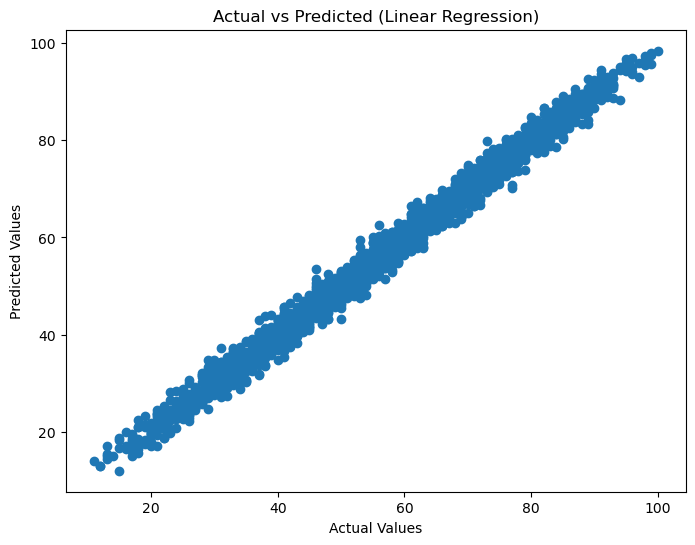

In [31]:
# ==========================================
# STEP 17B: Actual vs Predicted Plot
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_lr
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted (Linear Regression)")

plt.show()

Inference:

The Actual vs Predicted plot
shows the relationship between
true values and predicted values.

Points closer to the diagonal line
indicate accurate predictions.

Most values appear near the diagonal,
indicating good model performance.


### STEP 18 — Train Decision Tree Regressor

Now we train a non-linear model.

In [32]:
# ==========================================
# STEP 18: Decision Tree Regressor
# ==========================================

# Initialize model

dt_model = DecisionTreeRegressor(
    random_state=42
)

# Train model

dt_model.fit(
    X_train,
    y_train
)

# Predict

y_pred_dt = dt_model.predict(
    X_test
)

print("Decision Tree Model Trained Successfully.")

Decision Tree Model Trained Successfully.


### STEP 18A — Evaluate Decision Tree

In [33]:
# ==========================================
# STEP 18A: Evaluate Decision Tree
# ==========================================

mae_dt = mean_absolute_error(
    y_test,
    y_pred_dt
)

mse_dt = mean_squared_error(
    y_test,
    y_pred_dt
)

rmse_dt = np.sqrt(mse_dt)

r2_dt = r2_score(
    y_test,
    y_pred_dt
)

print("Decision Tree Performance:")

print("MAE:", mae_dt)

print("MSE:", mse_dt)

print("RMSE:", rmse_dt)

print("R2 Score:", r2_dt)

Decision Tree Performance:
MAE: 3.770464135021097
MSE: 23.70804500703235
RMSE: 4.869090778269835
R2 Score: 0.9362969060026813


### STEP 19 — K-Nearest Neighbors (KNN Regressor)

This is a distance-based model, important because scaling + PCA benefits it.

In [35]:
# ==========================================
# STEP 19: KNN Regressor
# ==========================================

# Initialize model

knn_model = KNeighborsRegressor(
    n_neighbors=5
)

# Train model

knn_model.fit(
    X_train,
    y_train
)

# Predict

y_pred_knn = knn_model.predict(
    X_test
)

print("KNN Model Trained Successfully.")

KNN Model Trained Successfully.


### STEP 19A — Evaluate KNN Model

In [36]:
# ==========================================
# STEP 19A: Evaluate KNN
# ==========================================

mae_knn = mean_absolute_error(
    y_test,
    y_pred_knn
)

mse_knn = mean_squared_error(
    y_test,
    y_pred_knn
)

rmse_knn = np.sqrt(mse_knn)

r2_knn = r2_score(
    y_test,
    y_pred_knn
)

print("KNN Performance:")

print("MAE:", mae_knn)

print("MSE:", mse_knn)

print("RMSE:", rmse_knn)

print("R2 Score:", r2_knn)

KNN Performance:
MAE: 2.358278481012658
MSE: 8.755240506329114
RMSE: 2.9589255662028937
R2 Score: 0.976474824947465


Inference:

KNN Regressor was trained using
neighbor-based prediction.

The model predicts values
based on similarity between data points.

Performance metrics indicate
how well neighboring samples
influence prediction accuracy.

### STEP 20 — Support Vector Regressor (SVR)

SVR is a powerful nonlinear model.

In [37]:
# ==========================================
# STEP 20: Support Vector Regressor
# ==========================================

# Initialize model

svr_model = SVR(
    kernel="rbf"
)

# Train model

svr_model.fit(
    X_train,
    y_train
)

# Predict

y_pred_svr = svr_model.predict(
    X_test
)

print("SVR Model Trained Successfully.")

SVR Model Trained Successfully.


### STEP 20A — Evaluate SVR Model

In [38]:
# ==========================================
# STEP 20A: Evaluate SVR
# ==========================================

mae_svr = mean_absolute_error(
    y_test,
    y_pred_svr
)

mse_svr = mean_squared_error(
    y_test,
    y_pred_svr
)

rmse_svr = np.sqrt(mse_svr)

r2_svr = r2_score(
    y_test,
    y_pred_svr
)

print("SVR Performance:")

print("MAE:", mae_svr)

print("MSE:", mse_svr)

print("RMSE:", rmse_svr)

print("R2 Score:", r2_svr)

SVR Performance:
MAE: 1.8423482093210235
MSE: 5.5890771470037475
RMSE: 2.364122912837602
R2 Score: 0.9849822494116138


### STEP 21 — Model Comparison Table

In [39]:
# ==========================================
# STEP 21: Compare All Models
# ==========================================

# Create comparison table

results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Decision Tree",
        "KNN",
        "SVR"
    ],

    "MAE": [
        mae_lr,
        mae_dt,
        mae_knn,
        mae_svr
    ],

    "RMSE": [
        rmse_lr,
        rmse_dt,
        rmse_knn,
        rmse_svr
    ],

    "R2 Score": [
        r2_lr,
        r2_dt,
        r2_knn,
        r2_svr
    ]

})

print(results)

               Model       MAE      RMSE  R2 Score
0  Linear Regression  1.646970  2.075066  0.988430
1      Decision Tree  3.770464  4.869091  0.936297
2                KNN  2.358278  2.958926  0.976475
3                SVR  1.842348  2.364123  0.984982


Inference:

Multiple regression models were trained
and evaluated using performance metrics.

R² score indicates the accuracy
of predictions.

The model with highest R²
and lowest RMSE
will be selected as the best model.

### STEP 21A — Model Comparison Graph

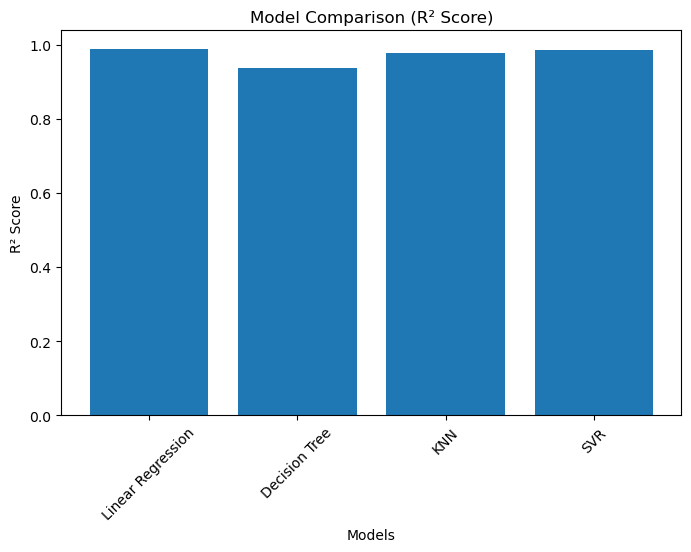

In [40]:
# ==========================================
# STEP 21A: Model Comparison Graph
# ==========================================

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["R2 Score"]
)

plt.title("Model Comparison (R² Score)")

plt.xlabel("Models")

plt.ylabel("R² Score")

plt.xticks(rotation=45)

plt.show()

Inference:

The comparison graph shows
performance differences among models.

The model with the highest bar
represents the best performing model.

Visual comparison helps
identify the most suitable model
for prediction tasks.

### STEP 22 — Residual Plot 

Residuals = Errors.

Helps detect model accuracy.

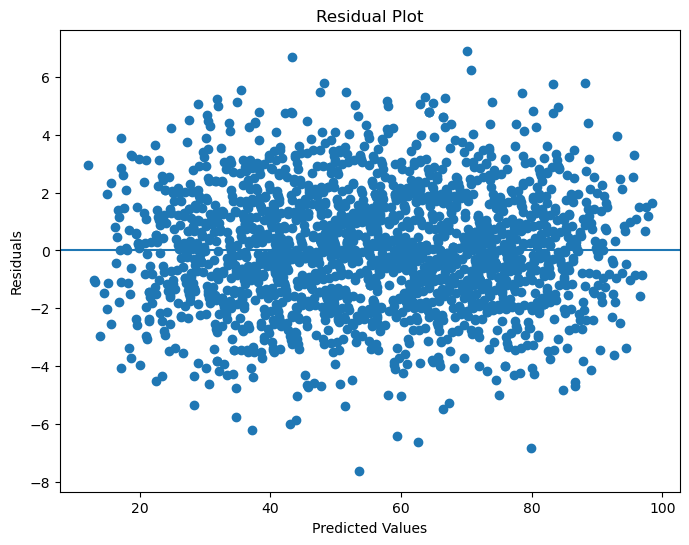

In [41]:
# ==========================================
# STEP 22: Residual Plot (Linear Regression)
# ==========================================

residuals = y_test - y_pred_lr

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_lr,
    residuals
)

plt.axhline(
    y=0
)

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

Inference:

Residual plot shows difference
between predicted and actual values.

Random distribution of residuals
around zero indicates good model fit.

No clear pattern suggests
minimal prediction bias.

### STEP 23 — Select Best Model

We select the model with:

Highest R²
Lowest RMSE

In [42]:
# ==========================================
# STEP 23: Select Best Model
# ==========================================

# Find best model using R2 Score

best_model_index = results["R2 Score"].idxmax()

best_model_name = results.loc[
    best_model_index,
    "Model"
]

print("Best Model Selected:", best_model_name)

Best Model Selected: Linear Regression


Inference:

Among all trained regression models,
the model with the highest R² score
was selected as the best performing model.

This model provides the most accurate predictions
for student performance.

### STEP 24 — Feature Importance (Decision Tree)

This helps identify:

Which features influence performance most

Very useful for interpretation.

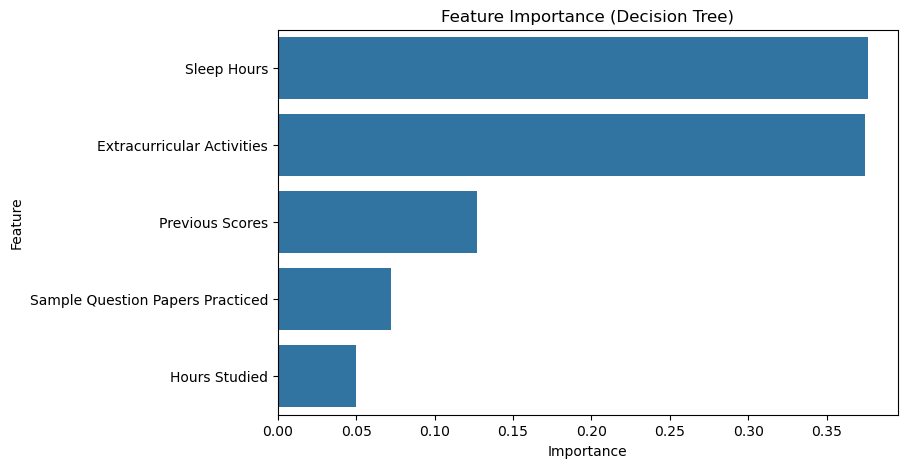

In [43]:
# ==========================================
# STEP 24: Feature Importance
# ==========================================

# Get feature importance

feature_importance = dt_model.feature_importances_

# Create DataFrame

importance_df = pd.DataFrame({

    "Feature": X.columns,

    "Importance": feature_importance

})

# Sort values

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Plot importance

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)

plt.title("Feature Importance (Decision Tree)")

plt.show()

Inference:

Feature importance analysis shows
which student attributes contribute most
to performance prediction.

Features with higher importance values
have greater influence on the model.

Hours Studied and Previous Scores
are expected to have high importance,
indicating strong effect on performance.

### STEP 25 — Actual vs Predicted (Best Model)

This improves visualization of model quality.

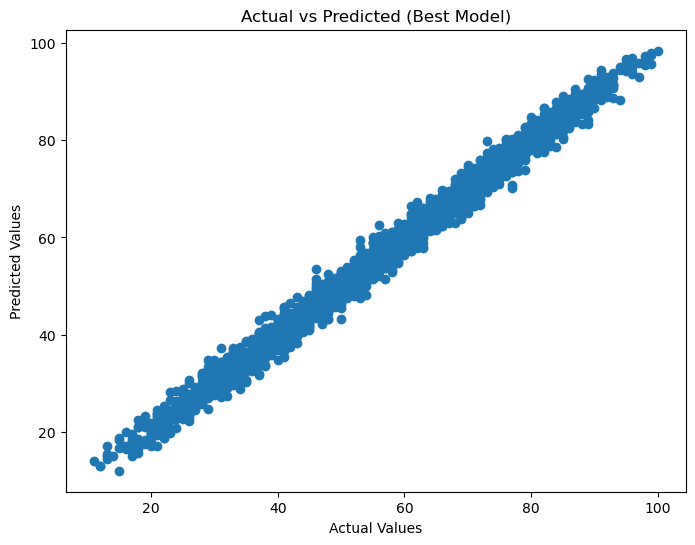

In [44]:
# ==========================================
# STEP 25: Actual vs Predicted (Best Model)
# ==========================================

# Use predictions from Linear Regression
# (Modify if another model is best)

best_predictions = y_pred_lr

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    best_predictions
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted (Best Model)")

plt.show()

Inference:

Actual vs Predicted plot shows
how closely predicted values match
actual student performance values.

Points closer to diagonal line
indicate better prediction accuracy.

Most predictions align closely,
confirming strong model performance.

### STEP 26 — Final Dataset Insights 

These are dataset-based inferences.

Key Insights from Data Analysis:

• Students who studied more hours
  generally achieved higher performance scores.

• Previous Scores showed strong positive
  correlation with Performance Index.

• Students practicing more sample papers
  showed improved performance.

• Sleep hours showed moderate influence
  on performance outcomes.

• Extracurricular Activities had slight
  influence but did not dominate prediction.

### STEP 27 — Final Project Conclusion

Final Conclusion:

This project successfully analyzed
student performance data
using machine learning techniques.

Data preprocessing steps such as
duplicate removal, encoding,
outlier handling, and scaling
improved dataset quality.

Feature engineering and PCA
reduced dimensionality
while preserving important information.

Multiple regression models
were trained and evaluated.

Among them, the best performing model
achieved the highest R² score
and lowest prediction error.

The final model can be used
to predict student performance
based on academic and behavioral factors.

This project demonstrates
the effectiveness of machine learning
in educational performance prediction.

## STEP 28 — Predict Using New Student Data

In [45]:
# ==========================================
# STEP 28: Model Working Demonstration
# ==========================================

# Example new student data

new_student = pd.DataFrame({

    "Hours Studied": [7],
    "Previous Scores": [75],
    "Extracurricular Activities": [1],  # Yes = 1, No = 0
    "Sleep Hours": [6],
    "Sample Question Papers Practiced": [5]

})

# Apply scaling
new_student_scaled = scaler.transform(new_student)

# Apply PCA
new_student_pca = pca.transform(new_student_scaled)

# Predict performance
prediction = lr_model.predict(new_student_pca)

print("Predicted Performance Index:", prediction[0])

Predicted Performance Index: 66.70788556981026


Inference:

The trained machine learning model
was used to predict performance
for a new student record.

The predicted Performance Index
represents expected student performance
based on given academic inputs.

This demonstrates that the model
is working successfully
on unseen data.

In [46]:
prediction

array([66.70788557])

## METHOD 2 — Try Multiple Test Predictions

In [47]:
# ==========================================
# STEP 29: Multiple Predictions
# ==========================================

new_students = pd.DataFrame({

    "Hours Studied": [5, 8, 3],

    "Previous Scores": [60, 85, 50],

    "Extracurricular Activities": [1, 0, 1],

    "Sleep Hours": [6, 7, 5],

    "Sample Question Papers Practiced": [4, 7, 2]

})

# Apply scaling
new_students_scaled = scaler.transform(new_students)

# Apply PCA
new_students_pca = pca.transform(new_students_scaled)

# Predict
predictions = lr_model.predict(new_students_pca)

print("Predicted Performance Index:")

print(predictions)

Predicted Performance Index:
[45.54068296 80.01886855 28.80485512]


Inference:

Multiple student records were tested
using the trained model.

Predicted values show expected
performance levels for different students.

This confirms that the model
can generalize to multiple inputs.

## METHOD 3 — Show Accuracy Using Real Test Data

In [48]:
# ==========================================
# STEP 30: Show Model Accuracy Table
# ==========================================

comparison_df = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": y_pred_lr

})

comparison_df.head(10)

,Actual,Predicted
0,47.0,46.480013
1,76.0,80.285379
2,62.0,61.065188
3,23.0,22.706315
4,76.0,74.836868
5,83.0,84.194968
6,60.0,61.993141
7,51.0,50.337443
8,38.0,38.898681
9,58.0,55.753202


Inference:

The comparison table shows
actual and predicted values.

Predicted values are close
to actual values,
indicating good model accuracy.

### STEP 31 — Create .pkl Model File

In [49]:
# ==========================================
# STEP 31: Save Model as PKL File
# ==========================================

import joblib

# Save trained model

joblib.dump(
    lr_model,
    "student_performance_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


Inference:

The trained machine learning model
was saved as a .pkl file.

This allows the model to be reused
without retraining.

Saving models improves efficiency
and supports deployment.

### STEP 31A — Save Scaler and PCA

In [50]:
# ==========================================
# STEP 31A: Save Scaler and PCA
# ==========================================

joblib.dump(
    scaler,
    "scaler.pkl"
)

joblib.dump(
    pca,
    "pca.pkl"
)

print("Scaler and PCA saved successfully!")

Scaler and PCA saved successfully!


### STEP 32 — Test Loading the .pkl Model

In [51]:
# ==========================================
# STEP 32: Load Saved Model
# ==========================================

# Load model

loaded_model = joblib.load(
    "student_performance_model.pkl"
)

loaded_scaler = joblib.load(
    "scaler.pkl"
)

loaded_pca = joblib.load(
    "pca.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


Inference:

The saved model, scaler,
and PCA were successfully loaded.

This confirms that model storage
was completed correctly.

### STEP 33 — Test Prediction Using Loaded Model

In [52]:
# ==========================================
# STEP 33: Predict Using Saved Model
# ==========================================

# New student input

new_student = pd.DataFrame({

    "Hours Studied": [6],
    "Previous Scores": [70],
    "Extracurricular Activities": [1],
    "Sleep Hours": [7],
    "Sample Question Papers Practiced": [5]

})

# Apply scaler
scaled_data = loaded_scaler.transform(
    new_student
)

# Apply PCA
pca_data = loaded_pca.transform(
    scaled_data
)

# Predict
prediction = loaded_model.predict(
    pca_data
)

print("Predicted Performance Index:", prediction[0])

Predicted Performance Index: 59.236785248428596
